# AdaBoost and GBDT

Random Forest is a representative algorithm of Bagging, while AdaBoost and GBDT are representative algorithms of Boosting

## 1.Algorithm Principles

### 1.1 Core Idea of the AdaBoost Algorithm

AdaBoost is an effective and practical Boosting algorithm that trains weak learners sequentially in a highly adaptive manner.

For classification problems, AdaBoost adjusts the weights of the training data based on the performance of the previous iteration. Samples that are misclassified by the previous weak learner are assigned higher weights in the next iteration, while correctly classified samples are assigned lower weights. At each iteration, a new weak learner is added to the model.

This process of updating weights and training weak learners continues until the number of misclassifications falls below a predefined threshold or the maximum number of iterations is reached. The final result is a strong learner.

In simple terms, the core idea of AdaBoost is to increase the weights of misclassified samples and iteratively improve the model.

In AdaBoost, it is typically predefined that the iteration stops when the number of misclassifications is zero (i.e., the error rate is 0). The error rate is defined as the sum of the weights of misclassified samples.

For example, suppose there are 9 samples, each with a weight of $\frac{1}{9}$. If 2 samples are misclassified, then the error rate is $\frac{2}{9}$



### 1.2 Simple Implementation of the AdaBoost Algorithm

AdaBoost can be applied to both classification and regression tasks. The corresponding models are AdaBoostClassifier and AdaBoostRegressor.

In AdaBoostClassifier, the weak learners are decision tree classifiers, while in AdaBoostRegressor, the weak learners are decision tree regressors.

In [1]:
# Example: AdaBoost Classification Model
from sklearn.ensemble import AdaBoostClassifier

# Import data
x = [[1,2],[3,4],[5,6],[7,8],[9,10]]
y = [0, 0, 0, 1, 1]

# Build up model
model = AdaBoostClassifier(random_state=0)

# Model training
model.fit(x,y)

# Make prediction
model.predict([[9,9]])

# Performance assessment
model.score(x,y)

1.0

In [2]:
# Example: AdaBoost Regression Model
from sklearn.ensemble import AdaBoostRegressor

# Import data
x = [[1,2],[3,4],[5,6],[7,8],[9,10]]
y = [1, 2, 3, 4, 5]

# Build up model
model = AdaBoostRegressor(random_state=10)

# Model training
model.fit(x,y)

# Make prediction
model.predict([[1,5],[7,9]])

# Performance assessment
model.score(x,y)

0.8

## 2.AdaBoost Algorithm Case Study: Targeted Credit Card Marketing Model

Case Background:
Nowadays, more and more people use credit cards for payments. Major commercial banks are investing increasing resources to expand their credit card business, leading to rapid growth in the industry. However, due to intense market competition and the high similarity among credit card products, banks are under pressure to adopt faster and more effective strategies to expand their customer base.

Therefore, implementing targeted (precision) marketing has become essential to reduce costs, improve efficiency, and enhance competitiveness.
In this case study, we build a targeted credit card marketing model. This model can also be applied to other domains of precision marketing, such as targeted promotion of financial products by trust companies.

In [3]:
import pandas as pd
import numpy as np

# Import data
df = pd.read_excel('Targeted Credit Card Marketing Model.xlsx')
df.head()

,Age,Monthly Income,Monthly Spending,Gender,Spending-to-Income Ratio,Response
0,30,7275,6062,0,0.833265,1
1,25,17739,13648,0,0.769378,1
2,29,25736,14311,0,0.556069,1
3,23,14162,7596,0,0.536365,1
4,27,15563,12849,0,0.825612,1


The ‘Response’ variable is our target variable, indicating whether the customer applied for a credit card after the marketing campaign. A value of 1 means the marketing was effective, while 0 means it was ineffective.

In [4]:
print(np.shape(df))
sum(df['Response'])

(1000, 6)


400

Among 1,000 individuals, 400 responded to the marketing campaign, while 600 did not.

In [5]:
# Extract feature variables and the target variable
x = df.drop(columns='Response')
y = df['Response']

# Split the dataset into a training set and a test set
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=123)

# Model training
from sklearn.ensemble import AdaBoostClassifier
clf = AdaBoostClassifier(random_state=123)
clf.fit(x_train,y_train)

# Prediction
y_pre = clf.predict(x_test)

# Performance assessment
a = pd.DataFrame()
a['Predicted values'] = list(y_pre)
a['Actual values'] = list(y_test)

from sklearn.metrics import accuracy_score
score = accuracy_score(y_pre,y_test)
print('Prediction accuracy: {}'.format(score))  

Prediction accuracy: 0.865


The weak learner in the AdaBoost classification model, "a decision tree", does not directly predict exact class labels (0 or 1). Instead, it estimates the probability of belonging to each class.

Evaluate model performance using the ROC curve

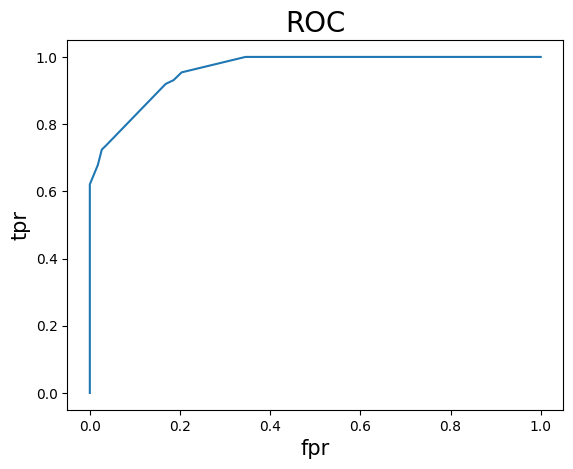

AUC:0.9602787102024208


In [6]:
y_pred_proba = clf.predict_proba(x_test)

from sklearn.metrics import roc_curve
fpr, tpr, thres = roc_curve(y_test.values, y_pred_proba[:,1])

import matplotlib.pyplot as plt
plt.plot(fpr,tpr)
plt.xlabel('fpr',fontsize=15)
plt.ylabel('tpr',fontsize=15)
plt.title('ROC',fontsize=20)
plt.show()

# Calculate the model’s AUC value
from sklearn.metrics import roc_auc_score
AUC = roc_auc_score(y_test.values, y_pred_proba[:,1])
print('AUC:{}'.format(AUC))       # AUC is around 0.96, which means the model has a good prediction performance

Compute the feature importance of each variable to identify the most important features for targeted marketing.

In [7]:
features = x.columns
importances = clf.feature_importances_
importances_df = pd.DataFrame()
importances_df['Feature name'] = features
importances_df['Feature importance'] = importances
importances_df.sort_values('Feature importance',ascending=False)  

,Feature name,Feature importance
4,Spending-to-Income Ratio,0.350091
2,Monthly Spending,0.324543
0,Age,0.299706
3,Gender,0.025660
1,Monthly Income,0.000000


## 2.GBDT

### 2.1 Core Idea of the GBDT Algorithm

GBDT stands for Gradient Boosting Decision Tree. It is a highly practical boosting algorithm.

The key difference between GBDT and AdaBoost lies in their learning mechanisms:

AdaBoost adjusts the weights of samples based on classification performance and iteratively builds a strong learner.

GBDT, on the other hand, treats the negative gradient of the loss function as an approximation of the residuals, and continuously fits these residuals using regression trees. Through this iterative process, a strong learner is constructed.

**In simple terms: AdaBoost focuses on adjusting sample weights, while GBDT focuses on fitting residual**

### 2.2 Simple Implementation of the GBDT Algorithm

In [8]:
# GBDT Classification Model
from sklearn.ensemble import GradientBoostingClassifier
x = [[1,2],[3,4],[5,6],[7,8],[9,10]]
y = [0,0,0,1,1]
model = GradientBoostingClassifier(random_state=123)
model.fit(x, y)
print(model.predict([[5,5],[9,9]]))

[0 1]


In [9]:
# GBDT Regression Model
from sklearn.ensemble import GradientBoostingRegressor
x = [[1,2],[3,4],[5,6],[7,8],[9,10]]
y = [1,2,3,4,5]
model = GradientBoostingRegressor(random_state=123)
model.fit(x, y)
print(model.predict([[5,5],[9,9]]))

[2.48347866 4.62221953]


### 2.3 GBDT Application: Product Pricing Model

Case Background:

When pricing books, publishers need to consider many factors such as the number of pages, paper quality, category, content, author, and target readers. Conducting such analysis manually is time-consuming and prone to omissions.

If a model can be developed to comprehensively take these factors into account, pricing decisions can become more scientific and efficient. This would help reduce costs, improve efficiency, meet customer needs, promote sales, and uncover additional potential profits.

Moreover, this product pricing model can also be extended to other domains, such as the pricing of financial products.

1. Model set up

In [10]:
# Import data
import pandas as pd
df = pd.read_excel('Product Pricing Model.xlsx')
df.head()

,Number of Pages,Category,Color Printing,Paper Type,Price
0,207,Technical,0,Woodfree Paper,60
1,210,Technical,0,Woodfree Paper,62
2,206,Technical,0,Woodfree Paper,62
3,218,Technical,0,Woodfree Paper,64
4,209,Technical,0,Woodfree Paper,60


In [11]:
# Use value_counts() to count and analyze the distribution of book categories
df['Category'].value_counts()

Category
Technical      336
Educational    333
Office         331
Name: count, dtype: int64

In [12]:
df['Paper Type'].value_counts()

Paper Type
Woodfree Paper    615
Coated Paper      196
Writing Paper     189
Name: count, dtype: int64

In [13]:
# Here, 0 represents black-and-white, and 1 represents color.
df['Color Printing'].value_counts()      

Color Printing
0    648
1    352
Name: count, dtype: int64

2. Processing Categorical Text Variables

In [14]:
# First, process the ‘Category’ column. It can also be converted into a one-hot encoded vector—use this depending on the situation
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Category'] = le.fit_transform(df['Category'])   # Convert text data into numerical data
df['Category'].value_counts()

Category
2    336
0    333
1    331
Name: count, dtype: int64

In [15]:
# Process the 'Paper Type' column.
df['Paper Type'] = le.fit_transform(df['Paper Type'])   # Convert text data into numerical data
df['Paper Type'].value_counts()

Paper Type
1    615
0    196
2    189
Name: count, dtype: int64

3. Extract feature variables and the target variable

In [16]:
x = df.drop(columns='Price')
y = df['Price']

4. Split the dataset into a training set and a test set

In [17]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.2, random_state=123)

5. Model Training & Building

In [18]:
from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor(random_state=123)
model.fit(x_train,y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

6. Prediction and performance assessment

In [19]:
y_pred = model.predict(x_test)
y_pred[0:50]

array([ 72.16634133,  77.27881252,  68.67647648,  89.97763921,
        78.4532028 ,  39.13146968,  39.64558689,  60.37132339,
        55.2505109 ,  77.79311028,  80.36788367,  76.60426403,
        81.00615176,  58.51223618,  79.90451433,  44.05226893,
        52.17034498,  36.71494345,  91.25459196,  58.51223618,
        42.05883161,  99.641047  ,  80.36788367,  79.67819315,
        92.1754665 ,  39.88816064,  45.43680033,  76.68338322,
        48.14102949,  62.50833127,  40.56847556,  61.28069331,
        95.94406155,  51.4486132 ,  64.3540023 ,  48.86637955,
        38.2279713 ,  83.33989296,  58.13401141, 101.67331586,
        48.59982381,  50.04648337,  34.15089599,  55.09471197,
        35.39880531,  34.77459273,  54.48791265,  75.39254867,
        36.71494345,  54.48791265])

In [20]:
# Compare predicted values and actual values
a = pd.DataFrame()
a['Predicted values'] = list(y_pred)
a['Actual values'] = list(y_test)
a.head(-1)

,Predicted values,Actual values
0,72.166341,75
1,77.278813,84
2,68.676476,68
3,89.977639,90
4,78.453203,85
...,...,...
194,47.180079,46
195,67.364723,68
196,76.604264,78
197,44.173389,44


In [21]:
# Evaluate model performance
score = model.score(x_test, y_test)
print(score)
# R^2
from sklearn.metrics import r2_score
r2 = r2_score(y_test, model.predict(x_test))
r = r2_score(y_test, y_pred)
print(r2)
print(r)


0.8729533469775136
0.8729533469775136
0.8729533469775136


In [22]:
features = x.columns
importances = model.feature_importances_

importances_df = pd.DataFrame()
importances_df['Feature name'] = features
importances_df['Feature importance'] = importances

importances_df.sort_values('Feature importance',ascending=False)

,Feature name,Feature importance
0,Number of Pages,0.499882
1,Category,0.427191
2,Color Printing,0.051563
3,Paper Type,0.021364
